In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import false_discovery_control
import os
from statsmodels.stats.multitest import fdrcorrection
from pybedtools.bedtool import BedTool

In [3]:
genes = pd.read_csv('/project2/yangili1/cfbuenabadn/torino_paper/code/resources/annotation/bed/Human.bed.gz', sep='\t',
                   names = ['chrom', 'start', 'end', 'gene_id', 'gene_name', 'strand'])

In [4]:
metadata = pd.read_csv('../code/results/tcga/ds/ds_sample_group.txt', sep='\t',
                       index_col = 0, names = ['condition', 'juncs', 'avleng', 'errQ'])
ds_cluster = pd.read_csv('../code/results/tcga/ds/leafcutter_ds/ds_cluster_significance.txt', sep='\t')
ds_effect = pd.read_csv('../code/results/tcga/ds/leafcutter_ds/ds_effect_sizes.txt', sep='\t')
junctions = pd.read_csv('../code/results/tcga/ds/leafcutter2.junction_counts.gz', sep=' ')
junctions.columns = ['junction'] + [x.split('.')[1] for x in junctions.columns[1:]]
junctions.columns = ['junction'] + list(junctions.columns[1:])

In [5]:
junctions_df = junctions[['junction']].copy()
# junctions_df.columns = ['junction']
junctions_df['chrom'] = junctions_df.junction.apply(lambda x: x.split(':')[0])
junctions_df['start'] = junctions_df.junction.apply(lambda x: x.split(':')[1])
junctions_df['end'] = junctions_df.junction.apply(lambda x: x.split(':')[2])
junctions_df['cluster'] = junctions_df.junction.apply(lambda x: x.split(':')[3])
junctions_df['strand'] = junctions_df.junction.apply(lambda x: x.split(':')[3].split('_')[-1])

junctions_df = junctions_df[['chrom', 'start', 'end', 'junction', 'cluster', 'strand']]
junctions_bed = BedTool.from_dataframe(junctions_df)
genes_bed = BedTool.from_dataframe(genes)

In [6]:
junctions_annot = junctions_bed.intersect(genes_bed, f=1, s = True, wao=True).to_dataframe(
    names = ['chrom', 'start', 'end', 'junction', 'cluster', 'strand', 
             'gene_chrom', 'gene_start', 'gene_end', 'gene_id', 'gene_name', 'gene_strand', 'overlap']
                                                                                    )

gene_id_count = junctions_annot.groupby("junction")["gene_id"].nunique()
gene_id_cluster = junctions_annot.groupby("cluster")["gene_id"].nunique()

junctions_annot["unique_gene_id_count"] = junctions_annot["junction"].map(gene_id_count)
junctions_annot["unique_gene_cluster_count"] = junctions_annot["cluster"].map(gene_id_cluster)

junctions_clean = junctions_annot.loc[(junctions_annot.overlap > 0) & (junctions_annot.unique_gene_cluster_count == 1)]

In [7]:
samples = list(junctions.columns[1:])


In [8]:
junctions = junctions.merge(junctions_clean)

In [9]:
junctions['observed_samples'] = (junctions[samples] > 0).sum(axis=1)
junctions['total_counts'] = junctions[samples].sum(axis=1)
junctions['junction_type'] = junctions.junction.apply(lambda x: x.rsplit(':', 1)[1])
junctions['junction'] = junctions.junction.apply(lambda x: x.rsplit(':', 1)[0])

In [10]:
obs_cluster = pd.DataFrame((junctions.groupby('cluster')[samples].sum() > 0).sum(axis=1))
obs_cluster.columns = ['obs_cluster']
junctions = junctions.merge(obs_cluster, left_on='cluster', right_index = True)

obs_cluster = pd.DataFrame((junctions.groupby('gene_id')[samples].sum() > 0).sum(axis=1))
obs_cluster.columns = ['obs_gene']
junctions = junctions.merge(obs_cluster, left_on='gene_id', right_index = True)

obs_cluster = pd.DataFrame(junctions.groupby('cluster').total_counts.sum())
obs_cluster.columns = ['cluster_counts']
junctions = junctions.merge(obs_cluster, left_on='cluster', right_index = True)


obs_cluster = pd.DataFrame(junctions.groupby('gene_id').total_counts.sum())
obs_cluster.columns = ['gene_counts']
junctions = junctions.merge(obs_cluster, left_on='gene_id', right_index = True)

In [11]:
junctions = junctions[[x for x in junctions.columns if not x.startswith('10')]]


In [12]:
junctions['avg_PSI'] = junctions.total_counts/junctions.cluster_counts
junctions['total_PSI'] = junctions.total_counts/junctions.gene_counts
junctions['cluster_PSI'] = junctions.cluster_counts/junctions.gene_counts

In [13]:
ds_cluster = ds_cluster.dropna()


(array([4979., 2058., 1688., 1401., 1278., 1167., 1139., 1041., 1003.,
         988.,  906.,  943.,  922.,  869.,  823.,  806.,  785.,  841.,
         785.,  784.,  803.,  754.,  774.,  735.,  709.,  762.,  756.,
         725.,  817., 1604.]),
 array([7.79519891e-29, 3.33333333e-02, 6.66666667e-02, 1.00000000e-01,
        1.33333333e-01, 1.66666667e-01, 2.00000000e-01, 2.33333333e-01,
        2.66666667e-01, 3.00000000e-01, 3.33333333e-01, 3.66666667e-01,
        4.00000000e-01, 4.33333333e-01, 4.66666667e-01, 5.00000000e-01,
        5.33333333e-01, 5.66666667e-01, 6.00000000e-01, 6.33333333e-01,
        6.66666667e-01, 7.00000000e-01, 7.33333333e-01, 7.66666667e-01,
        8.00000000e-01, 8.33333333e-01, 8.66666667e-01, 9.00000000e-01,
        9.33333333e-01, 9.66666667e-01, 1.00000000e+00]),
 <BarContainer object of 30 artists>)

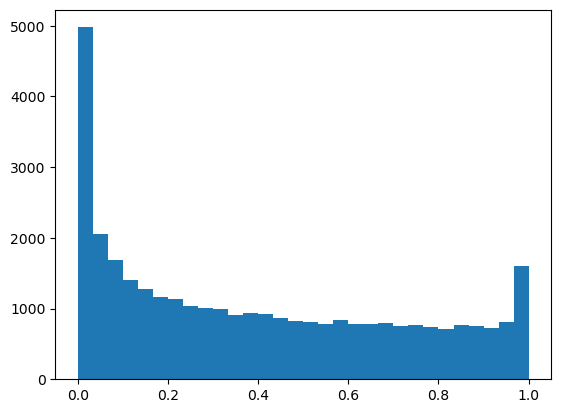

In [14]:
plt.hist(np.array(ds_cluster.dropna()['p']), bins=30)

In [15]:
ds_cluster['cluster'] = ds_cluster.cluster.apply(lambda x: x.split(':')[1])
junctions = junctions.merge(ds_effect, left_on='junction', right_on='intron')
junctions = junctions.merge(ds_cluster, on = 'cluster')

In [16]:
cluster_types = (
    junctions.groupby('cluster')['junction_type']
    .apply(lambda x: ','.join(sorted(set(x))))
    .reset_index()
    .rename(columns={'junction_type': 'cluster_type'})
)


junctions = junctions.merge(cluster_types, on='cluster')

In [17]:
junctions.loc[(junctions.cluster_type == 'PR,UP') & (
    junctions['p.adjust'] <= 0.05) & (junctions.junction_type == 'UP') & (junctions.df == 1)]

,junction,110221,110260,110262,110268,110270,110349,110356,110359,110364,...,logef,Control,Primary_tumor,deltapsi,status,loglr,df,p,p.adjust,cluster_type
434,chr1:11837157:11837342:clu_443_+,8,11,8,11,6,8,6,7,3,...,-0.640434,9.296385e-01,0.785882,-0.143756,Success,4.863958,1.0,0.001815,0.044133,"PR,UP"
9125,chr1:121177333:121181270:clu_6286_-,59,5,0,4,16,20,0,1,19,...,0.754347,4.764925e-01,0.804490,0.327997,Success,7.113684,1.0,0.000162,0.009176,"PR,UP"
31722,chr5:44811155:44811914:clu_21728_+,123,95,57,32,58,176,99,104,100,...,0.836547,9.639099e-01,0.993023,0.029113,Success,4.925225,1.0,0.001698,0.042374,"PR,UP"
36287,chr6:31628240:31629143:clu_25168_+,355,51,50,59,69,228,40,101,98,...,0.880593,9.401821e-01,0.989185,0.049003,Success,6.585926,1.0,0.000284,0.013410,"PR,UP"
46744,chr8:98950756:98951518:clu_33583_+,4,5,5,0,12,13,23,15,5,...,0.407216,2.701139e-01,0.455217,0.185103,Success,6.257526,1.0,0.000404,0.016543,"PR,UP"
52820,chr9:120865831:120866027:clu_37932_-,43,7,11,7,15,19,0,1,24,...,-6.297168,9.999999e-01,0.965539,-0.034461,Success,4.823034,1.0,0.001898,0.045311,"PR,UP"
56509,chr10:20809899:20812768:clu_40518_-,1,0,0,0,0,0,0,0,1,...,6.043480,3.871988e-08,0.006827,0.006827,Success,5.354819,1.0,0.001066,0.031927,"PR,UP"
62306,chr11:36495048:36497107:clu_44686_-,0,0,0,0,16,8,0,10,13,...,-2.301051,4.738304e-01,0.008952,-0.464878,Success,5.050340,1.0,0.001482,0.039426,"PR,UP"
71791,chr13:28357686:28384884:clu_51392_-,5,11,8,4,10,3,7,10,20,...,-7.658205,1.000000e+00,0.884885,-0.115115,Success,5.302864,1.0,0.001127,0.033167,"PR,UP"
78664,chr15:60468323:60476062:clu_56443_-,23,5,8,12,16,33,3,10,24,...,0.341241,4.175924e-01,0.586573,0.168981,Success,5.926457,1.0,0.000576,0.021169,"PR,UP"


In [18]:
cluster_total = pd.DataFrame(junctions.groupby('cluster').total_counts.sum())
cluster_total.columns = ['cluster_counts']

In [19]:
junctions.loc[(junctions.cluster_type == 'PR,UP') & (junctions['p.adjust'] <= 1e-2) & (junctions.junction_type == 'UP')].deltapsi.median()

np.float64(-0.00034358021076645)

In [20]:
delta_up = junctions.loc[(junctions.cluster_type == 'PR,UP') & (junctions.junction_type == 'UP') & (junctions.avg_PSI >= 0.2) & (junctions.cluster_counts >= 100000)].logef
p_up = -np.log10(junctions.loc[(junctions.cluster_type == 'PR,UP') & (junctions.junction_type == 'UP') & (junctions.avg_PSI >= 0.2) & (junctions.cluster_counts >= 100000)].p)

In [21]:
np.mean(junctions.loc[(junctions.cluster_type == 'PR,UP') & (junctions.junction_type == 'UP') & (junctions.avg_PSI >= 0.2) & (junctions.cluster_counts >= 5000) & (junctions['p.adjust'] <= 1e-10)].deltapsi > 0)

np.float64(1.0)

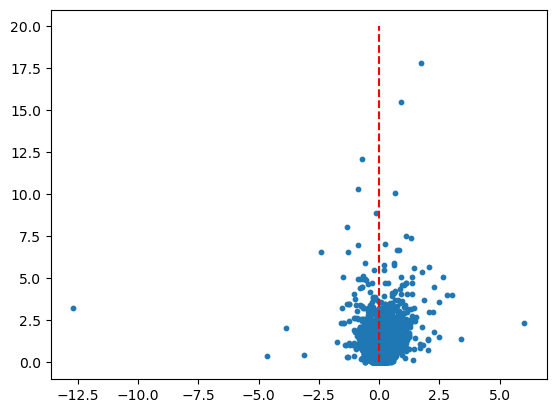

In [22]:
plt.scatter(delta_up, p_up, s=10)
plt.plot([0, 0], [0, 20], 'r--')
# plt.xlim([-2, 2])

In [23]:
junctions_up = junctions.loc[(junctions.cluster_type == 'PR,UP')]

In [24]:
from adjustText import adjust_text

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


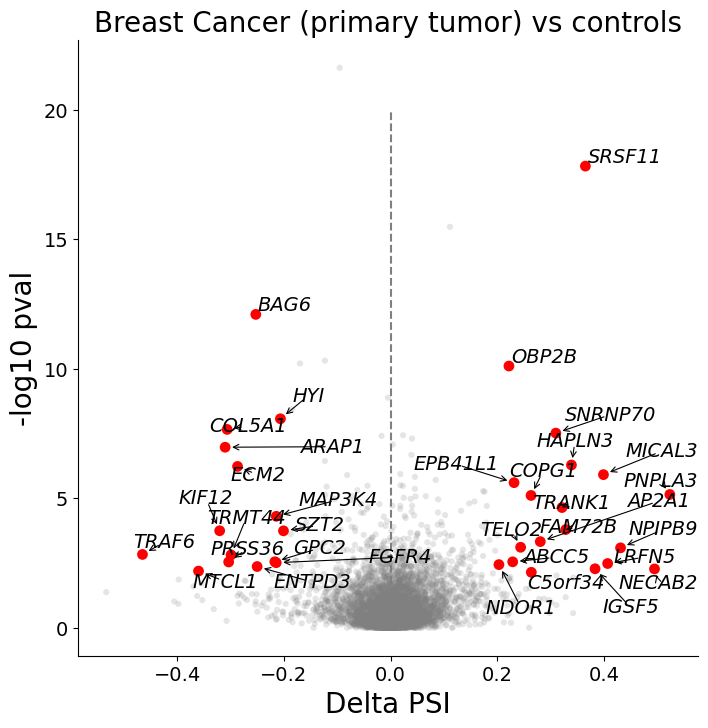

In [25]:
up_obs = 0
up_sig = 0
up_increase = 0
fig, ax = plt.subplots(figsize= (8, 8))

up_delta = []
p_list_up = []
sig_delta = []
sig_p = []

gene_list = []

p_list_up_total = []

# up_p_list = []

TEXTS = []
# for i in range(len(penguins)):
#     if NAMES[i].startswith("C"):
#         x = penguins["flipper_length_mm"].iloc[i]
#         y = penguins["bill_length_mm"].iloc[i]
#         text = NAMES[i]
#         TEXTS.append(ax.text(x, y, text, color=GREY30, fontsize=14, fontname="Poppins"))

for clu, df in junctions_up.groupby('cluster'):
    upd = df.loc[df.junction_type == 'UP'].sort_values('total_counts', ascending=False).iloc[0].deltapsi
    avg_p = df.loc[df.junction_type == 'UP'].sort_values('total_counts', ascending=False).iloc[0].avg_PSI
    pval = df.loc[df.junction_type == 'UP'].sort_values('total_counts', ascending=False).iloc[0].p
    counts = df.loc[df.junction_type == 'UP'].sort_values('total_counts', ascending=False).iloc[0].total_counts
    gene = df.loc[df.junction_type == 'UP'].sort_values('total_counts', ascending=False).iloc[0].gene_name
    fdr = df.loc[df.junction_type == 'UP'].sort_values('total_counts', ascending=False).iloc[0]['p.adjust']
    
    p_list_up_total.append(pval)
    
    if (avg_p >= 1e-1) & (counts >= 100):
        up_obs += 1
        up_delta.append(upd)
        p_list_up.append(pval)
        if (np.abs(upd) >= 0.2) and (fdr <= 1e-1):
            sig_delta.append(upd)
            sig_p.append(pval)
            gene_list.append(gene)
            TEXTS.append(ax.text(upd, -np.log10(pval), gene, color='black', fontsize=14, fontstyle="italic"))
            
#             up_p_list.append(pval)
            
            up_sig += 1
            if upd > 0 :
                up_increase += 1

                         
ax.scatter(up_delta, -np.log10(np.array(p_list_up)), s=20, edgecolor='none', facecolor='gray', alpha=0.2, rasterized=True)
ax.scatter(sig_delta, -np.log10(np.array(sig_p)), s=60, edgecolor='none', facecolor='red', alpha=1, rasterized=True)

ax.plot([0, 0], [0, 20], linestyle='--', c='gray')

adjust_text(
    TEXTS, 
    expand_points=(3, 3),
    arrowprops=dict(
        arrowstyle="->", 
        color='black', 
        lw=0.8,
        shrinkA=5,   # shrink arrow from text side
        shrinkB=5 
    ),
    ax=fig.axes[0]
)

ax.set_xlabel('Delta PSI', fontsize=20)
ax.set_ylabel('-log10 pval', fontsize=20)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Breast Cancer (primary tumor) vs controls', fontsize=20)
ax.tick_params(axis='both', labelsize=14)

# ax.text(-0.4, 22, 'Total: 749\nSignificant: 41\nIncrease: 33 (80.5%)', fontsize=14)

plt.savefig(f'breast_cancer_unproductive_splicing.pdf', bbox_inches='tight', dpi=500)
plt.savefig(f'breast_cancer_unproductive_splicing.svg', bbox_inches='tight', dpi=500)
plt.savefig(f'breast_cancer_unproductive_splicing.png', bbox_inches='tight', dpi=500)

In [26]:
np.median(np.array(sig_delta)>0)

np.float64(1.0)

In [28]:
np.mean(np.array(sig_delta) > 0)

np.float64(0.5588235294117647)

In [31]:
np.array(gene_list)[np.array(sig_delta) < 0]

array(['SZT2', 'ENTPD3', 'TRMT44', 'FGFR4', 'MAP3K4', 'BAG6', 'GPC2',
       'COL5A1', 'ECM2', 'KIF12', 'TRAF6', 'ARAP1', 'HYI', 'PRSS36',
       'MTCL1'], dtype='<U7')